# 1. Importing the data and modules

the data was downloaded yousing the following *Google Earth Engine* script: https://code.earthengine.google.com/04afb4de7a1d95d988d2972e3ed87ffd.
--> downloads image from July 1st of the START year of each 3-year block

Band positions: 
1. Blue
2. Green 
3. Red 
4. NIR 
5. SWIR1
6. SWIR2
7. TIR1


In [229]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cmcrameri.cm as cmc

In [230]:
year_list = np.arange(1985, 2025, 3) # array with al the year we have data from
LST = xr.Dataset()

LST_array = []
Red_array = []
NIR_array = []
for year in year_list:
        filepath = f"../data/raw/LandsatComposite_Zurich_{year}.tif"
        with xr.open_dataset(filepath, engine = "rasterio") as src:
            src_t = src.expand_dims(time=[year])# add time as a coordinate
            LST_array.append(src_t.sel(band = 7).band_data)
            Red_array.append(src_t.sel(band = 3).band_data)
            NIR_array.append(src_t.sel(band = 4).band_data)


LST = xr.concat(LST_array, dim="time")# turn into xr data array
Red = xr.concat(Red_array, dim = "time")
NIR = xr.concat(NIR_array, dim = "time")


# 2. Analyse Trends in NDVI and LST
## 2.1 calculate NDVI

In [231]:
# extract year values from data Cube
NIR_2024 = NIR.sel(time = 2024)
Red_2024 = Red.sel(time = 2024)
NIR_1985 = NIR.sel(time = 1985)
Red_1985 = Red.sel(time = 1985)

# calculate NDVO for each year

NDVI_2024 = (NIR_2024 - Red_2024)/(NIR_2024 + Red_2024)
NDVI_1985 = (NIR_1985 - Red_1985)/(NIR_1985 + Red_1985)

## 2.2 Map of the differences in NDVI and LST

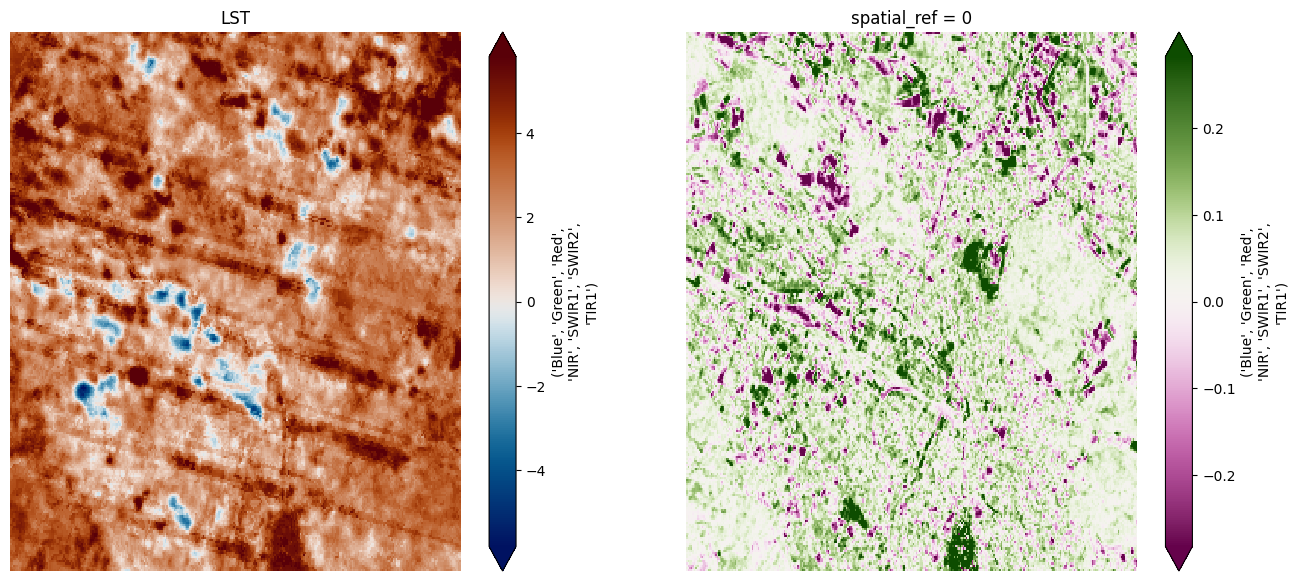

In [232]:
# extract year values from data Cube
LST_2024 = LST.sel(time = 2024)
LST_1985 = LST.sel(time = 1985)

dif_NDVI = NDVI_2024 - NDVI_1985 
dif_LST = LST_2024 - LST_1985 

fig , ax = plt.subplots(1,2, figsize = (16,7))

#determine vmin/max LST
LST_min = np.percentile(dif_LST, 2)# percentile to crop outliers
LST_max = np.percentile(dif_LST.values, 98)
LST_bound = max(abs(LST_min), abs(LST_max))# center around 0
#plot LST
dif_LST.plot(ax=ax[0],
            vmin = - LST_bound, 
            vmax = LST_bound,
            cmap = cmc.vik)
ax[0].set_axis_off()
ax[0].set_title("LST")

#determine vmin/max NDVI
NDVI_min = np.percentile(dif_NDVI, 2)# percentile to crop outliers
NDVI_max = np.percentile(dif_NDVI, 98)
NDVI_bound = max(abs(NDVI_min), abs(NDVI_max))# center around 0
#plot NDVI
dif_NDVI.plot(ax=ax[1], 
              vmin = -NDVI_bound, 
              vmax = NDVI_bound,
              cmap = cmc.bam)

ax[1].set_axis_off()
## note: for reference: add lables, context etc. lake etc...> mask for lake

##  2.2 Change in Time
### mean change

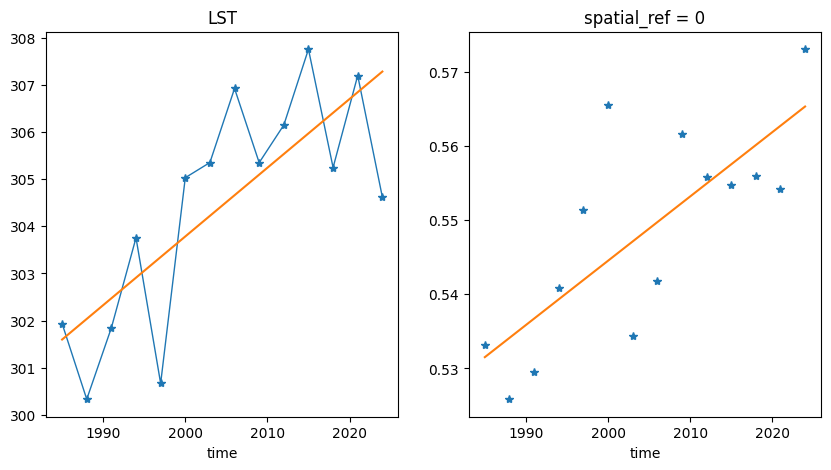

In [233]:
# change in overall NDVI
NDVI = NDVI = (NIR - Red)/(NIR + Red)
NDVI_mean = NDVI.mean(dim =["x","y"])

NDVI_mean_fit = NDVI_mean.polyfit(dim = "time", deg = 1)
NDVI_mean_trend_line = xr.polyval(NDVI.time, NDVI_mean_fit.polyfit_coefficients)

# change in overall LST
LST_mean = LST.mean(dim =["x","y"])
LST_mean_fit = LST_mean.polyfit(dim = "time", deg = 1)
LST_mean_trend_line = xr.polyval(LST.time, LST_mean_fit.polyfit_coefficients)

#plotting
fig, ax = plt.subplots(1,2, figsize = (10,5))

LST_mean.plot(ax = ax[0],marker = "*", linewidth = 1)
LST_mean_trend_line.plot(ax = ax[0])
ax[0].set_title("LST")

NDVI_mean.plot(ax = ax[1], marker = "*", linewidth = 0)
NDVI_mean_trend_line.plot(ax= ax[1])


### overall changes

Text(0.5, 1.0, 'Modeled NDVI change (1985-2024)')

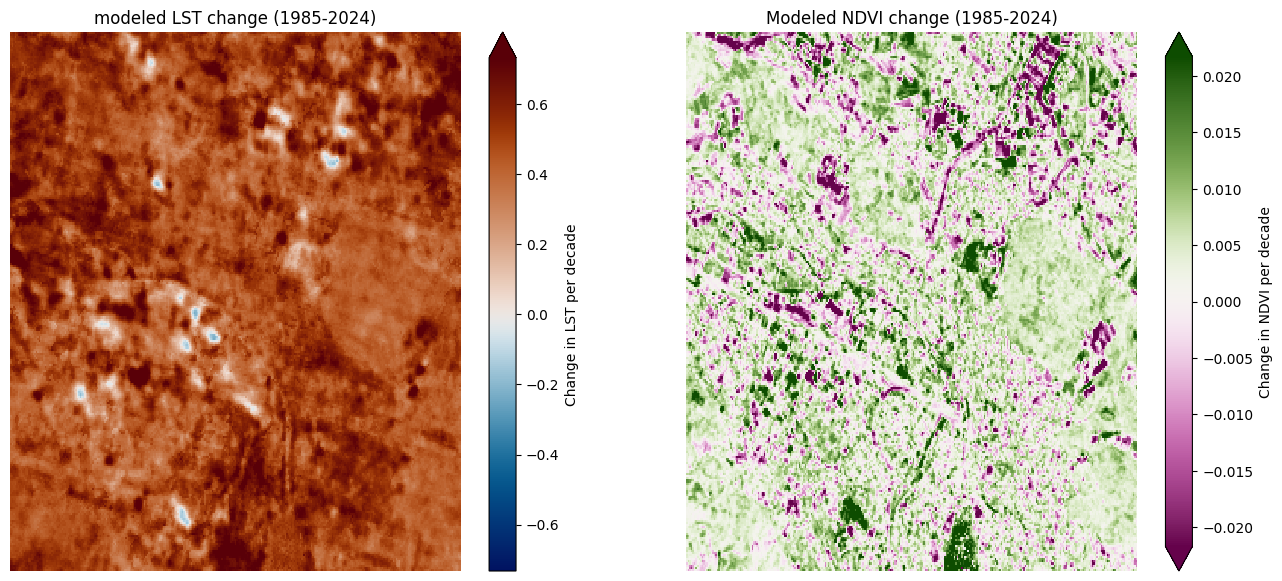

In [234]:

NDVI_fit = NDVI.polyfit(dim = "time", deg = 1)
NDVI_slope10 = NDVI_fit.polyfit_coefficients.sel(degree = 1)/3*10

# change in overall LST
LST_fit = LST.polyfit(dim = "time", deg = 1)
LST_slope10 = LST_fit.polyfit_coefficients.sel(degree = 1)/3*10 # slope is in 3 year increments (int not dateTime!)

#plotting
fig, ax = plt.subplots(1,2, figsize = (16,7))

# plot slope of LST
LST_slope_min = np.percentile(LST_slope10, 2)# percentile to crop outliers
LST_slope_max = np.percentile(LST_slope10, 98)
LST__slope_bound = max(abs(LST_slope_min), abs(LST_slope_max))


LST_slope10.plot(ax=ax[0], 
                 vmin = - LST__slope_bound, 
                 vmax = LST__slope_bound, 
                 cmap = cmc.vik,
                 cbar_kwargs = {"label" : "Change in LST per decade"})
ax[0].set_axis_off()
ax[0].set_title("modeled LST change (1985-2024)")

#plot slope of NDVI
NDVI_slope_min = np.percentile(NDVI_slope10, 2)# percentile to crop outliers
NDVI_slope_max = np.percentile(NDVI_slope10, 98)
NDVI__slope_bound = max(abs(NDVI_slope_min), abs(NDVI_slope_max))

NDVI_slope10.plot(ax= ax[1], 
                  vmin = - NDVI__slope_bound, 
                  vmax = NDVI__slope_bound, 
                  cmap = cmc.bam, 
                  cbar_kwargs = {"label" : "Change in NDVI per decade"})
ax[1].set_axis_off()
ax[1].set_title("Modeled NDVI change (1985-2024)")